# LAB 3: Electrocardiograms and Neural Networks

In this lab, we will predict heart arrhythmia with LSTMs and 1-D CNNs.

We will use MIT-BIH Arrythmia dataset (https://www.physionet.org/content/mitdb/1.0.0/).
It consists of ECG recordings of several patients with sample rate 360 per second. Experts annotated/classified specific points in the signals as normal, abnormal, or non beat.

**NOTE 1:** GPU is required for this lab.
You must change "Runtime type" to GPU from the "Runtime" tab ("Change Runtime type").

**NOTE 2:** If you face RAM/memory overflow issue in this lab, ensure that you train only one model in single COLAB session. Feel free to implement your own memory optimization tricks too.

**NOTE 3** Google currently offers free Colab Pro for students for one year:
https://blog.google/products-and-platforms/products/education/colab-higher-education/
I recommend signing up for it. It will make your life much easier and save you a lot of waiting time.

In [1]:
# Install the package you need for this lab
# You may need to install them every time you restart the runtime
%pip install wfdb

In [2]:
# Feel free to add more libraries if you need them
import os
import wfdb
import numpy as np
import pandas as pd
import urllib.request
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy.signal

In [3]:
# Load database, this will take a few minutes

path_dataset = 'mba_dataset/mit-bih-arrhythmia-database-1.0.0/'

# Check if the data folder exists
if not os.path.exists(path_dataset):
    print("Dataset not found. Downloading and unzipping...")

    # Download the zip file
    url = 'https://physionet.org/static/published-projects/mitdb/mit-bih-arrhythmia-database-1.0.0.zip'
    urllib.request.urlretrieve(url, './mba_dataset.zip')

    # Unzip the contents
    !unzip -q mba_dataset.zip -d mba_dataset
else:
    print("Dataset already exists.")

Dataset already exists.


## Explore database

We will primarily use \<patientID>.atr files (patientID is being 100, 101, etc.). There are 48 patients with a 30 minutes of recording for each.
For patient '200', let us check what annotations are present in his/her signal. Run the code below.

In [4]:
# We provide function for loading an ECG file
def load_ECG_file(path):
    '''
    Input: path for patient files (excluding extension)
    Output: ECG signal, symbols (labels), indices for such symbols
    '''
    record = wfdb.rdrecord(path)
    annotation = wfdb.rdann(path, 'atr')
    signal = record.p_signal[:,0]    # ECG signal
    symbol = annotation.symbol  # symbols
    index = annotation.sample  # annotation index
    return signal, symbol, index
signal, symbol, index = load_ECG_file(os.path.join(path_dataset, '200'))  # check for yourself if "signal" is ~30 min duration
print(f'Length of signal: {signal.shape}.\n{type(signal)=}\n')  # ECG signal length (in terms of samples and NOT seconds); think why this corresponds to ~30 minutes of signal
print(f'Annotation symbols: {symbol}.\n{type(symbol)=}')  # annotation symbols
print(len(symbol), "\n")
print(f'Annotation indices: {index}.\n{type(index)=}')  # annotion indices of symbols for patient
print(len(index), "\n")

Length of signal: (650000,).
type(signal)=<class 'numpy.ndarray'>

Annotation symbols: ['+', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', '+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'V', 'N', 'V', 'N', 'V', 'V', 'N', 'V', 'N', 'V', 'V', 'N', 'V', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'V', 'N', 'V', 'V', 'N', 'V', 'N', 'N', '+', 'V', 'N', 'V', 'N', 'V', '+', 'N', 'N', '+', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', '+', 'N', 'N', '+', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', '+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'V', 'N', 'V', 'V', 'N', '+', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', '+', 'N', 'N', 'N', '+', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', '+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', '+', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', 'N', '+', 'V', 'V', 'V', '+', 'N', 'V', 'N', 'V', 'N', 'V', 'N', 'V', '+', 'N', 'N

We can see a lot of 'N' symbols. It refers to "normal" heartbeat.
The list of abnormal symbols are provided below, which we will consider as "abnormal" beats in this lab.
Any other symbol encountered in the dataset refer to "non-beat" and you **must** skip them in data preparation.
For detailed explanation about symbols, refer to https://archive.physionet.org/physiobank/annotations.shtml

In [5]:
# list of symbols for abnormal beats
abnormal = ['L','R','V','/','A','f','F','j','a','E','J','e','S']

# NOTE: Create an abnoraml set for faster access time
abnormal_set = set(abnormal)

## TASK 1 Data visualization (10 points)
---
Plot any random 10-second long portion of this ECG file (patient 200). Then plot any 1-second portion of this ECG file (patient 200) which has an abnormality approximately in the middle of the signal.

1. How many samples are in a 10-second window?

    Answer:

        For a 10 second window there would be a 10 * 360 = 3600 interval

2. If you want a 1-second window centered at an R-peak index
r, what slice indices would you use (in samples) to get the correct length? Express this as a Python slice: `signal[start:end]`

    Answer:

    start = R-peak - (360 / 2)

    end = start + 360 

    slice = signal[start:end]

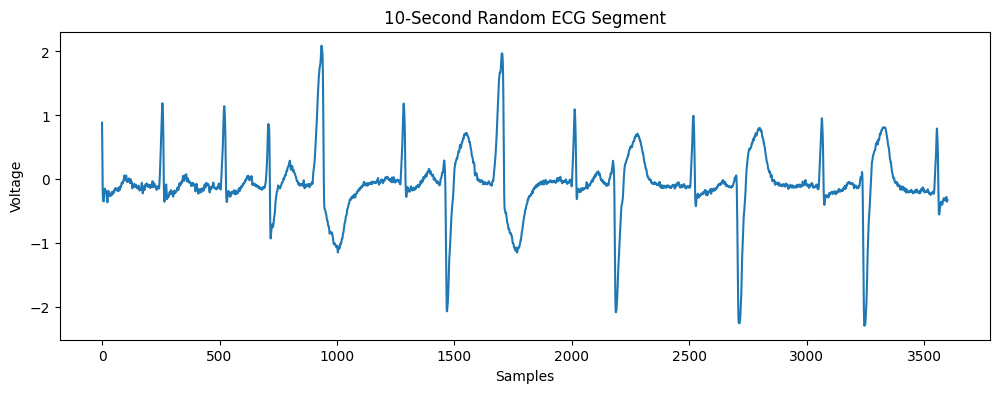

In [6]:
# Plot 1
# Your code here

# Get a random 10-second segment of the ECG signal
fs = 360  # sampling frequency in Hz
segment_length = 10 * fs  # number of samples in a 10-second segment
start_index = np.random.randint(0, len(signal) - segment_length)
segment = signal[start_index:start_index + segment_length]

plt.figure(figsize=(12, 4))
plt.plot(segment)
plt.title("10-Second Random ECG Segment")
plt.xlabel("Samples")
plt.ylabel("Voltage")
plt.show()

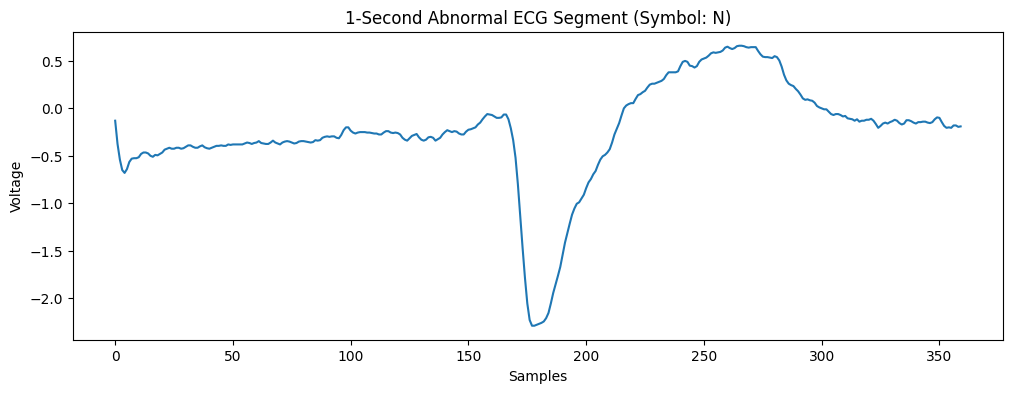

In [7]:
# Plot 2
# Your code here

# Get the indices of abnormal beats
abnormal_indices = [index[i] for i in range(len(symbol)) if symbol[i] in abnormal_set]
# Get the corresponding symbols for the abnormal beats
abnormal_symbols = [symbol[i] for i in range(len(symbol)) if symbol[i] in abnormal_set]

# Get a random 1 second abnormal segment of the ECG signal where the beat is located in the middle of the segment
abnormal_segment_length = fs  # number of samples in a 1-second segment
random_abnormal_index = np.random.choice(abnormal_indices)      
segment_start = random_abnormal_index - abnormal_segment_length // 2
segment_end = segment_start + abnormal_segment_length       # NOTE: that i am adding to segment start here and not to random_abnormal_index so that the data length is 1 second 

# Ensure the segment is within the bounds of the signal
if segment_start < 0:
    segment_start = 0
    segment_end = abnormal_segment_length
elif segment_end > len(signal):
    segment_end = len(signal)
    segment_start = segment_end - abnormal_segment_length
    
    
abnormal_segment = signal[segment_start:segment_end]
plt.figure(figsize=(12, 4))
plt.plot(abnormal_segment)
plt.title(f"1-Second Abnormal ECG Segment (Symbol: {symbol[abnormal_indices.index(random_abnormal_index)]})")
plt.xlabel("Samples")
plt.ylabel("Voltage")
plt.show()

##TASK 2 Data preparation (10 points):
---
Training data or test data is usually represented by a matrix $X \in \mathbb{R}^{N\times D}$. N represents the number of training points, and D represents the data dimension. We will consider one data point as +/- 0.5 seconds sequence of samples centered around a normal or abnormal symbol. Therefore, $D = f$ , where $f$ is the sample rate. Your goal is to construct such data matrix $X$. Your function should also output the corresponding label vector $y \in \mathbb{R}^{N\times 1}$. Labels should be 0 for Normal and 1 for abnormal. You should get close to a total of 100k data points.

**Note 1:** Don't forget to ingore the non-beat symbols.

**Note 2:** Labels in abnormal list should all be set with label 1.

**Note 3:** The patients in the training set should be different from the patients in the test set. We have split the patients for you and you can simply use the patient IDs below.

**Note 4** There might be cases where the 1 second segment also contains other beats. For the simplicity of this lab we can just assume each segment contains exactly one
beats


Why is 𝐷=𝑓? You can either explain with plain language or prove with simple math.


Answer:

In [8]:
# training patient IDs
pts_train = ['100','101','102','103','104','105','106','107',
       '108','109','111','112','113','114','115','116',
       '117','118','119','121','122','123','124','200',
       '201','202','203','205','207','208','209','210']

# testing patient IDs
pts_test = ['212','213','214','215','217','219','220','221',
       '222','223','228','230','231','232','233','234']

In [9]:
def make_dataset(pts, num_sec, fs, abnormal):
    '''
    Create a dataset from ECG signals by extracting specific segments around heartbeats
    and labeling them based on the presence of abnormalities.

    Parameters:
    - pts: List of patient identifiers to load ECG files for processing.
    - num_sec: Number of seconds to include before and after each heartbeat in the extracted segment.
    - fs: Sampling frequency of the ECG signals, used to calculate the number of samples in each segment.
    - abnormal: List of abbreviations for abnormalities to look for in the ECG signals.

    Returns:
    - X_all (numpy.ndarray): signal (nbeats , 2 * num_sec * fs columns
    - Y_all (numpy.ndarray): binary is abnormal (nbeats, 1)
    '''

    # Make an empty list to store the segments and labels
    X_all = []
    Y_all = []
    
    # Total number of samples in a segment
    num_cols = int(2 * num_sec * fs)
    
    # Iterate over all patient IDs
    for pt in tqdm(pts, desc="Processing Patients"):
        # Load the ECG file for the current patient
        path = os.path.join(path_dataset, pt)
        p_signal, symbol, index = load_ECG_file(path)
        
        # Create a DataFrame for easy filtering
        df_ann = pd.DataFrame({'symbol': symbol, 'index': index})
        
        # NOTE: Ignore non-beat symbols by filtering only for N symbols
        valid_symbols = ['N'] + abnormal
        df_ann = df_ann[df_ann['symbol'].isin(valid_symbols)]
        
        # Get the indices specifically for abnormal beats
        ab_idx = df_ann[df_ann['symbol'].isin(abnormal)]['index'].values
        
        X, Y = build_XY(p_signal, df_ann, num_cols, ab_idx, abnormal)
        X_all.append(X)
        Y_all.append(Y)
        
    # Stack all patient matrices into one large dataset
    X_all = np.vstack(X_all)
    Y_all = np.vstack(Y_all)
        
    return X_all, Y_all


def build_XY(p_signal, df_ann, num_cols, ab_idx, abnormal):
    '''
    Build the X (signal segments) and Y (abnormality labels) matrices for each beat.

    Parameters:
    - p_signal: The full ECG signal array.
    - df_ann: DataFrame containing filtered heartbeat annotations.
    - num_cols: The total number of samples per extracted segment.
    - ab_idx: Numpy array containing indices of abnormal beats.
    - abnormal: List of abnormal beat abbreviations.
    - num_sec: Number of seconds before and after each heartbeat for segment extraction.
    - fs: Sampling frequency (Hz).

    Returns:
    - X (numpy.ndarray): Extracted heartbeat signal segments.
    - Y (numpy.ndarray): Binary labels indicating abnormality presence.
    '''

    X = []
    Y = []
    
    # Number of samples on either side of the R-peak (e.g., 180 samples)
    half_cols = num_cols // 2
    
    for _, row in df_ann.iterrows():
        r_peak = row['index']
        sym = row['symbol']
        
        start_idx = r_peak - half_cols
        end_idx = r_peak + half_cols
        
        # Ensure the slice doesn't go out of array bounds
        if start_idx >= 0 and end_idx <= len(p_signal):
            # Extract the 1D signal array for this beat
            segment = p_signal[start_idx:end_idx]
            X.append(segment)
            
            # NOTE: Labels in the abnormal list should all be set with label 1
            label = 1 if sym in abnormal else 0
            Y.append([label])
            
    return np.array(X), np.array(Y)


num_sec = 0.5
fs = 360
X_train, y_train = make_dataset(pts_train, num_sec, fs, abnormal)
X_test, y_test = make_dataset(pts_test, num_sec, fs, abnormal)

Processing Patients: 100%|██████████| 16/16 [00:01<00:00, 13.30it/s]


In [10]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(70384, 360) (70384, 1) (39021, 360) (39021, 1)


In [11]:
np.sum(y_train,axis=1).sum()/70384

np.float64(0.3084081609456695)

## Task 3 Feature extraction (10 points)
---
You will use Signal Processing library [scipy.signal](https://docs.scipy.org/doc/scipy/reference/signal.html) to extract features for training and testing data matrices. We will do consecutive Fourier transforms to extract the spectrogram of ECG signal.

**Note 1:** A common format of spectrogram is a graph with two geometric dimensions: one axis represents time, and the other axis represents frequency; a third dimension indicating the amplitude of a particular frequency at a particular time is represented by the intensity or color of each point in the image.

Examples of ECG spectrogram are shown below:

![ECG_spetrogram.jpg](https://d3i71xaburhd42.cloudfront.net/c86f76b6eeaa1ae92e5c96a68ca47d046fc01b2e/3-Figure2-1.png)

M. Salem, S. Taheri and J. Yuan, "ECG Arrhythmia Classification Using Transfer Learning from 2- Dimensional Deep CNN Features," 2018 IEEE Biomedical Circuits and Systems Conference (BioCAS), Cleveland, OH, USA, 2018, pp. 1-4, doi: 10.1109/BIOCAS.2018.8584808.

In [12]:
def extract_features(X):
    # Set nperseg to create a proper sequence of time steps
    frequencies, times, Sxx = scipy.signal.spectrogram(X, fs=360, nperseg=64, noverlap=32)
    
    # Sxx shape is (N, Freqs, Times). 
    # For LSTM (batch_first=True), we want (N, Times, Freqs)
    F = np.transpose(Sxx, axes=(0, 2, 1))
    return F

# Extract features for both datasets
F_train = extract_features(X_train)
F_test = extract_features(X_test)

print("Training features shape:", F_train.shape)
print("Testing features shape:", F_test.shape)

Training features shape: (70384, 10, 33)
Testing features shape: (39021, 10, 33)


## Task 4 Distribution and compensation for imbalance (10 points)
---
Plot the distribution of percentage of oberservations with normal and abnormal labels in training set. Is the dataset balanced? If not, how could you compensate it during training? Would it be helpful?

Answer:

Text(0.5, 1.0, 'Training Set Distribution')

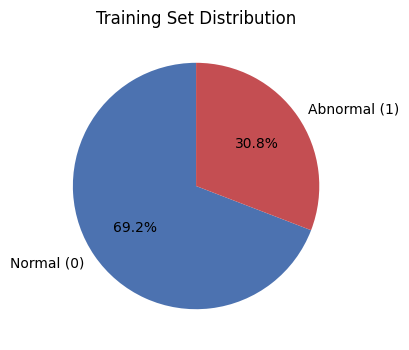

In [13]:
# Train
# Your code here
# 
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
# Calculate counts
train_abnormal = np.sum(y_train)
train_normal = len(y_train) - train_abnormal

# Create Pie Chart
plt.pie([train_normal, train_abnormal], labels=['Normal (0)', 'Abnormal (1)'], 
        autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'], startangle=90)
plt.title("Training Set Distribution")

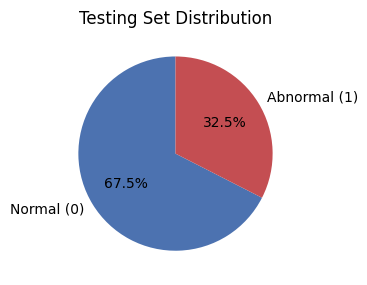

In [14]:
# Test
# Your code here

plt.subplot(1, 2, 2)
# Calculate counts
test_abnormal = np.sum(y_test)
test_normal = len(y_test) - test_abnormal

# Create Pie Chart
plt.pie([test_normal, test_abnormal], labels=['Normal (0)', 'Abnormal (1)'], 
        autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'], startangle=90)
plt.title("Testing Set Distribution")

plt.tight_layout()
plt.show()

Write your own BCE loss function and explain briefly how it can help when you have an imbalanced data set.

Answer:

In [15]:
def mybce(yhat, y, pos_weight, eps=1e-7):
    """
    Custom Binary Cross-Entropy (BCE) loss function with numerical stability and adjustable positive class weight.

    Parameters:
    - yhat (Tensor): Predicted probabilities (should be in the range [0, 1])
    - y (Tensor): Ground truth labels (0 or 1)kkk
    - pos_weight (float): Weight for the positive class to handle class imbalance
    - eps (float): Small constant to prevent log(0) errors

    Returns:
    - loss (Tensor): Computed BCE loss
    """
    # Clip yhat for numerical stability
    y_hat = torch.clamp(yhat, min=eps, max=1.0 - eps)
    
    # Calculate weighted BCE loss
    loss = - (pos_weight * y * torch.log(y_hat) + (1 - y) * torch.log(1 - y_hat))
    
    return torch.mean(loss)

**Note:** Be careful when you create your own BCE weighted loss functions, you are required to use this loss instead of nn.BCEWithLogitsLoss in your following task.

# Implementing Neural Networks

In the tasks below you will implement various neural networks you have seen in the lectures. You will train your neural network with the ECG data you have explored above and report the performance of your models.

**Note:** You will be asked to use only torch.nn.Sequential in Task 6 and only torch.nn.Module in Task 7. Points will be deducted if you fail to follow the instructions even if your model is correct

## TASK 5 LSTM (35 points total)
---
 Now, we are going to train a classifier to detect abnormal ECG cycles. We will train a simplified version of the LSTM-based network described in one of the [previously cited papers](https://www.sciencedirect.com/science/article/pii/S0010482518300738?casa_token=qrJ6hAf9tkYAAAAA:7uXqrKY5WqUM6Mjc_qg7wJ4R6QA02BGFXP0o_pOKN09yB8JIXb7067JZWY88rZc8M1G6gkkA).


**Note 1:** Printing loss function and accuracy while training to make sure your model works.

**Note 2:** You need to add a flattening layer after LSTM layer (and before linear layer).

**Note 3:** The output of LSTM in pytorch lib have a tuple outout, add the following GetLSTMOutput after your layer

**Note 4:** You should use the BCE loss fcuntion you implemented above

In [16]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score,f1_score
from torch.utils.data import TensorDataset, DataLoader

In [178]:
# Adapt your input to tensor
F_train = torch.from_numpy(F_train).float()
F_test= torch.from_numpy(F_test).float()
y_train = torch.from_numpy(y_train).float()
y_test = torch.from_numpy(y_test).float()

In [203]:
batch_size = 1024
learning_rate = 0.001
num_epochs = 30

In [215]:
# NORMALIZE
# Apply log transform to compress the extreme power values in the spectrogram
F_train_log = np.log(F_train + 1e-8)
F_test_log = np.log(F_test + 1e-8)

# Standardize (Z-score) using the training set statistics
mean_F = F_train_log.mean()
std_F = F_train_log.std()

F_train_norm = (F_train_log - mean_F) / std_F
F_test_norm = (F_test_log - mean_F) / std_F

# Convert the normalized arrays to PyTorch tensors
X_train_tensor = torch.from_numpy(F_train_norm).float()
X_test_tensor = torch.from_numpy(F_test_norm).float()
y_train_tensor = torch.from_numpy(y_train).float()
y_test_tensor = torch.from_numpy(y_test).float()

In [216]:
# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), 
                          batch_size=1024, shuffle=True, pin_memory=True, num_workers=2)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), 
                         batch_size=1024, shuffle=False, pin_memory=True, num_workers=2)

In [205]:
class GetLSTMOutput(nn.Module):
    def forward(self, x):
        out,_ = x
        return out

### Task 5.1 (8 points)
 Using Pytorch, create a single layer Bidirectional LSTM model using torch.nn.Sequential (i.e. you should NOT use torch.nn.Module). Followed by LSTM layer, you should have linear layer with sigmoid activation and number of output units equals to 1.

   **Note:** You should not use torch.nn.Module. Points will be deducted if you do even if the function is correct

In [217]:
# Define hyperparameters
input_size = 33    # Number of frequency bins from spectrogram
hidden_size = 64
num_layers = 1

In [ ]:
hidden_size = 64

model_LSTM = nn.Sequential(
    # Add dropout=0.5 directly to the LSTM layer
    nn.LSTM(input_size=33, hidden_size=hidden_size, num_layers=2, 
            batch_first=True, bidirectional=True, dropout=0.5),
    GetLSTMOutput(),
    nn.Flatten(),
    # Add an explicit Dropout layer before the fully connected layer
    nn.Dropout(0.5), 
    nn.Linear(hidden_size * 2 * 10, 1),
    nn.Sigmoid()
)

### Task 5.2 (2 points)

Define your model, loss function and optimizer. The loss function should be the one you implemented above in Task 5.

In [209]:
# Define model, loss function and optimizer.
# Your code here
# 
# Set device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_LSTM.to(device)

# Calculate weight for imbalance: (total samples - positive samples) / positive samples
num_pos = y_train_tensor.sum().item()
num_neg = len(y_train_tensor) - num_pos
pos_weight_val = num_neg / num_pos

optimizer = torch.optim.Adam(model_LSTM.parameters(), lr=learning_rate)


### Task 5.3 (10 points)

Train and test your model.

Plot loss and accuracy with respect to training epochs.

Report your accuracy on test set and training set.

You are required to use the dataloaders you created earlier for mini-batcing

You need to train the model for at least 20 epochs

In [210]:
# Train the model
# Your code here

# HACK: 
train_losses = []
train_accuracies = []

# --- TRAINING LOOP ---
for epoch in range(num_epochs):
    model_LSTM.train()
    epoch_loss = 0
    all_preds = []
    all_targets = []
    
    for X_batch, y_batch in train_loader:
        # Move batch data to the GPU
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Forward pass
        yhat = model_LSTM(X_batch)
        
        # Compute loss using your custom BCE function
        loss = mybce(yhat, y_batch, pos_weight)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        #  Track predictions for accuracy calculation
        preds = (yhat >= 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())
        
    # Calculate epoch metrics
    avg_loss = epoch_loss / len(train_loader)
    train_acc = accuracy_score(all_targets, all_preds)
    
    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {train_acc:.4f}")


Epoch [1/30], Loss: 0.4449, Accuracy: 0.8726
Epoch [2/30], Loss: 0.1798, Accuracy: 0.9590
Epoch [3/30], Loss: 0.1396, Accuracy: 0.9705
Epoch [4/30], Loss: 0.1163, Accuracy: 0.9757
Epoch [5/30], Loss: 0.1022, Accuracy: 0.9790
Epoch [6/30], Loss: 0.0915, Accuracy: 0.9815
Epoch [7/30], Loss: 0.0828, Accuracy: 0.9838
Epoch [8/30], Loss: 0.0732, Accuracy: 0.9855
Epoch [9/30], Loss: 0.0658, Accuracy: 0.9870
Epoch [10/30], Loss: 0.0612, Accuracy: 0.9878
Epoch [11/30], Loss: 0.0572, Accuracy: 0.9892
Epoch [12/30], Loss: 0.0552, Accuracy: 0.9898
Epoch [13/30], Loss: 0.0498, Accuracy: 0.9905
Epoch [14/30], Loss: 0.0464, Accuracy: 0.9910
Epoch [15/30], Loss: 0.0490, Accuracy: 0.9905
Epoch [16/30], Loss: 0.0418, Accuracy: 0.9920
Epoch [17/30], Loss: 0.0381, Accuracy: 0.9930
Epoch [18/30], Loss: 0.0344, Accuracy: 0.9938
Epoch [19/30], Loss: 0.0323, Accuracy: 0.9938
Epoch [20/30], Loss: 0.0326, Accuracy: 0.9943
Epoch [21/30], Loss: 0.0315, Accuracy: 0.9944
Epoch [22/30], Loss: 0.0279, Accuracy: 0.99

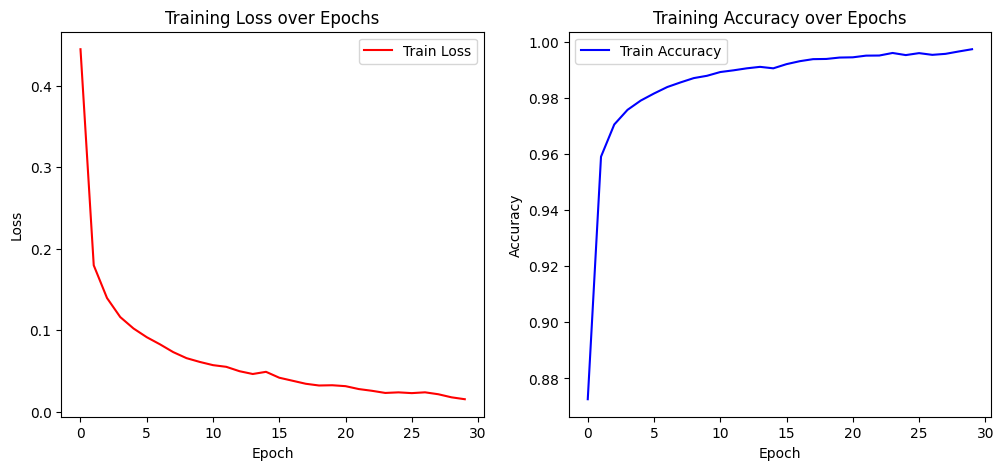

In [213]:
# --- PLOTTING ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='red')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='blue')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



In [214]:

# --- EVALUATION ON TEST SET ---
model_LSTM.eval()
test_preds = []
test_targets = []

with torch.no_grad(): 
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        yhat = model_LSTM(X_batch)
        preds = (yhat >= 0.5).float()
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(y_batch.cpu().numpy())

test_acc = accuracy_score(test_targets, test_preds)
test_f1 = f1_score(test_targets, test_preds)

print(f"Final Training Accuracy: {train_accuracies[-1]:.2%}")
print(f"Test Accuracy: {test_acc:.2%}%")
print(f"Test F1-Score: {test_f1:.4f}")

Final Training Accuracy: 99.73%
Test Accuracy: 58.56%%
Test F1-Score: 0.4840


### Task 5.4 (15 points): Pooling for `model_LSTM` (mean vs max)

In Task 5.1, you implemented `model_LSTM` using `nn.Sequential`. The LSTM returns a **sequence** of outputs over time, so before the final `nn.Linear(...)` you must convert that sequence into a fixed-length vector for each sample.

In Task 5.1, the LSTM output has shape `(B, T, F)` (batch, time, features). A linear layer expects a 2D tensor `(B, D)`, so `nn.Flatten()` was used to reshape:
- from `(B, T, F)` to `(B, T*F)`

This keeps **all time steps** by concatenating them into one long vector.

#### How pooling is different from flattening
Pooling also converts `(B, T, F)` into a 2D tensor, but it does so by **aggregating over the time dimension**:
- Flatten: `(B, T, F) -> (B, T*F)` (concatenate time steps)
- Pooling: `(B, T, F) -> (B, F)` (summarize time)

In this task, you will replace `nn.Flatten()` with one of two pooling operations:

1) **Mean pooling** over time: average across the `T` dimension  
2) **Max pooling** over time: elementwise maximum across the `T` dimension

#### What you need to do
Create **two versions** of `model_LSTM` that differ only in the pooling layer:
- `model_LSTM` with **mean pooling**
- `model_LSTM` with **max pooling**

Keep everything else identical to Task 5.3:
- You must use `torch.nn.Sequential`
- same `train_loader` / `test_loader` (mini-batching),
- same loss function `mybce`,
- same optimizer setup (Adam + same learning rate),
- same number of epochs,
- threshold 0.5 for converting probabilities to predicted labels.

#### What to report
Print exactly two lines using the format below:

```
Pooling=mean, Train Loss=..., Train Acc=...%, Test Acc=...%, Test F1=...
```
```
Pooling=max, Train Loss=..., Train Acc=...%, Test Acc=...%, Test F1=...
```



In [ ]:
class MeanPooling(nn.Module):
    def forward(self, x):
        # x shape is (Batch, Time, Features)
        # We take the mean across the Time dimension (dim=1)
        return x.mean(dim=1)

class MaxPooling(nn.Module):
    def forward(self, x):
        # x.max(dim=1) returns a tuple of (values, indices). 
        # We only want the values [0].
        return x.max(dim=1)[0]

In [ ]:
# Your code here

# Helper function to build, train, and evaluate a model
def train_and_eval_pooling(pooling_type, pooling_layer):
    #
    # Define hyperparameters
    # Your code here

    input_size = 129  
    hidden_size = 129
    num_layers = 2
    dropout_rate = 0.5  # 50% of neurons will be dropped during training

    learning_rate = 0.001
    num_epochs = 30

    # Build the model using the specific pooling layer instead of Flatten
    model = nn.Sequential(
        nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, 
                batch_first=True, bidirectional=True),
        GetLSTMOutput(),
        pooling_layer,
        nn.Linear(hidden_size * 2, 1),
        nn.Sigmoid()
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # training Loop
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        all_preds = []
        all_targets = []
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            yhat = model(X_batch)
            loss = mybce(yhat, y_batch, pos_weight)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
            preds = (yhat >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())
            
    # final Training Metrics
    train_loss = epoch_loss / len(train_loader)
    train_acc = accuracy_score(all_targets, all_preds)
    
    # Testing Loop
    model.eval()
    test_preds = []
    test_targets = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            yhat = model(X_batch)
            preds = (yhat >= 0.5).float()
            test_preds.extend(preds.cpu().numpy())
            test_targets.extend(y_batch.cpu().numpy())
            
    test_acc = accuracy_score(test_targets, test_preds)
    test_f1 = f1_score(test_targets, test_preds)
    
    # Print the exact format required by the lab
    print(f"Pooling={pooling_type}, Train Loss={train_loss:.4f}, Train Acc={train_acc*100:.2f}%, Test Acc={test_acc*100:.2f}%, Test F1={test_f1:.4f}")


In [ ]:
train_and_eval_pooling("mean", MeanPooling())
train_and_eval_pooling("max", MaxPooling())

Pooling=mean, Train Loss=0.4056, Train Acc=89.26%, Test Acc=74.18%, Test F1=0.6091
Pooling=max, Train Loss=0.3988, Train Acc=89.53%, Test Acc=75.64%, Test F1=0.6152


Compare BiLSTM performance with **no pooling** (`nn.Flatten()`), **mean pooling**, and **max pooling**. Which is best on test F1? Does pooling help? Briefly explain why pooling improved or hurt performance in your case.

Answer:

## TASK 6 1-D CNNs (25 points total)
---
In addition to a LSTM model, we will use [1D CNN](https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html) with ReLU activation. You need to add a flattening layer just after this (and before linear layer).



**Note 1:** Printing loss function and accuracy while training to make sure your model works.

**Note 2:** You need to add a flattening layer after CNN layer (and before linear layer).

**Note 3:** Sigmoid is recommended as the activation of your last linear layer.

**Note 4:** You should use the loss fcuntion you implemented above

### Task 6.1 (10 points)

 Using Pytorch, create a deep CNN model (more than 1 layer) subclassing torch.nn.Module (i.e. you should NOT use torch.nn.Sequential). Followed by CNN layer, you should have one or several linear layers with different kinds of activation and number of final output units equals to 1.

  **Note:** You should not use torch.nn.Sequential. Points will be deducted if you do even if the function is correct

In [ ]:


# Define hyperparameters
# Your code here
learning_rate = 0.001
num_epochs = 20
# We will reuse the train_loader and test_loader with batch_size=256 from Task 5

# Create the CNN model using nn.Module
# Your code here
# 
in_channels = 1     # Our input is a 1D sequence, so we have 1 channel
conv1_filters = 16  # Number of feature detectors in the first layer
conv2_filters = 32  # Number of feature detectors in the second layer
kernel_sz = 3       # The size of the sliding window (looks at 3 time steps at once)
pool_sz = 2         # Cuts the sequence length in half to compress information
fc_hidden = 64      # Number of neurons in the dense layer
dropout_rate = 0.5  # Drops 50% of neurons to prevent overfitting

### Task 6.2 (2 points)

 While creating your deep CNN model, how do you validate your model and optimize the hyperparameters (hidden size, learning rate) and optimizer for your model? (Design your method and show how it works in this task)

In [ ]:
# Define model, loss function and optimizer

# Your code here
# 
class CNN1D(nn.Module):
    def __init__(self):
        super(CNN1D, self).__init__()
        
        # 1. First Convolutional Block
        self.conv1 = nn.Conv1d(in_channels=in_channels, out_channels=conv1_filters, 
                               kernel_size=kernel_sz, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=pool_sz) 
        # Length goes from 129 -> 64
        
        # 2. Second Convolutional Block
        self.conv2 = nn.Conv1d(in_channels=conv1_filters, out_channels=conv2_filters, 
                               kernel_size=kernel_sz, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=pool_sz) 
        # Length goes from 64 -> 32
        
        # 3. Flattening Layer (Required by Note 2)
        self.flatten = nn.Flatten()
        
        # 4. Fully Connected Layers
        # Input features: 32 filters * 32 remaining sequence length = 1024
        self.fc1 = nn.Linear(conv2_filters * 32, fc_hidden)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        
        # 5. Output Layer (Required by Note 3)
        self.fc2 = nn.Linear(fc_hidden, 1)
        self.sigmoid = nn.Sigmoid() 

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.dropout(self.relu3(self.fc1(x)))
        out = self.sigmoid(self.fc2(x))
        return out

### Task 6.3 (10 points)

Train and test your model.

Plot loss and accuracy with respect to training epochs.

Report your accuracy on test set and train set.

You need to train the model for at least 20 epochs

In [ ]:
# Instantiate model and push to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_CNN = CNN1D().to(device)

# We reuse the pos_weight calculated in Task 5 to handle class imbalance
criterion = mybce 

# Setup the optimizer using our defined hyperparameter
optimizer_cnn = torch.optim.Adam(model_CNN.parameters(), lr=learning_rate)

Epoch [1/20], Loss: 0.9358, Accuracy: 63.08%
Epoch [2/20], Loss: 0.7427, Accuracy: 76.37%
Epoch [3/20], Loss: 0.6362, Accuracy: 79.35%
Epoch [4/20], Loss: 0.5930, Accuracy: 81.12%
Epoch [5/20], Loss: 0.5489, Accuracy: 84.72%
Epoch [6/20], Loss: 0.5028, Accuracy: 86.94%
Epoch [7/20], Loss: 0.4689, Accuracy: 87.89%
Epoch [8/20], Loss: 0.4414, Accuracy: 88.61%
Epoch [9/20], Loss: 0.4133, Accuracy: 89.36%
Epoch [10/20], Loss: 0.3872, Accuracy: 89.97%
Epoch [11/20], Loss: 0.3679, Accuracy: 90.56%
Epoch [12/20], Loss: 0.3553, Accuracy: 90.85%
Epoch [13/20], Loss: 0.3394, Accuracy: 91.18%
Epoch [14/20], Loss: 0.3289, Accuracy: 91.42%
Epoch [15/20], Loss: 0.3185, Accuracy: 91.84%
Epoch [16/20], Loss: 0.3096, Accuracy: 91.91%
Epoch [17/20], Loss: 0.2973, Accuracy: 92.09%
Epoch [18/20], Loss: 0.2912, Accuracy: 92.20%
Epoch [19/20], Loss: 0.2819, Accuracy: 92.41%
Epoch [20/20], Loss: 0.2774, Accuracy: 92.43%


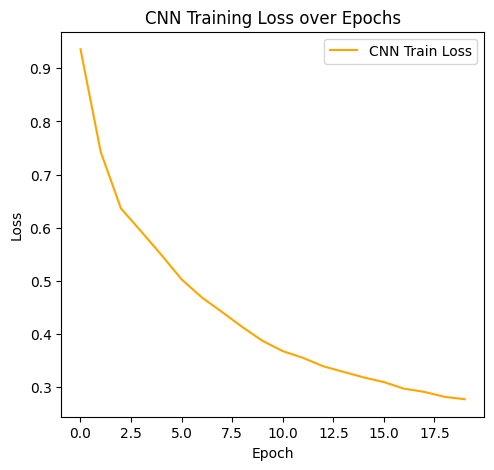

In [ ]:
cnn_train_losses = []
cnn_train_accuracies = []

# --- TRAINING LOOP ---
for epoch in range(num_epochs):
    model_CNN.train()
    epoch_loss = 0
    all_preds = []
    all_targets = []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Forward pass
        yhat = model_CNN(X_batch)
        
        # Compute custom loss
        loss = criterion(yhat, y_batch, pos_weight)
        
        # Backward pass & optimize
        optimizer_cnn.zero_grad()
        loss.backward()
        optimizer_cnn.step()
        
        epoch_loss += loss.item()
        
        # Track accuracy
        preds = (yhat >= 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())
        
    avg_loss = epoch_loss / len(train_loader)
    train_acc = accuracy_score(all_targets, all_preds)
    
    cnn_train_losses.append(avg_loss)
    cnn_train_accuracies.append(train_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {train_acc*100:.2f}%")
# --- PLOTTING ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_train_losses, label='CNN Train Loss', color='orange')
plt.title('CNN Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [ ]:
# --- EVALUATION ON TEST SET ---
model_CNN.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        yhat = model_CNN(X_batch)
        preds = (yhat >= 0.5).float()
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(y_batch.cpu().numpy())

test_acc = accuracy_score(test_targets, test_preds)
test_f1 = f1_score(test_targets, test_preds)

print(f"\nFinal CNN Train Accuracy: {cnn_train_accuracies[-1]*100:.2f}%")
print(f"CNN Test Accuracy: {test_acc*100:.2f}%")
print(f"CNN Test F1-Score: {test_f1:.4f}")


Final CNN Train Accuracy: 92.43%
CNN Test Accuracy: 76.17%
CNN Test F1-Score: 0.6160


##Task 7 Alexnet (125 points total)
---
 AlexNet is a deep convolutional neural network (CNN) designed by Alex Krizhevsky, Ilya Sutskever, and Geoffrey Hinton, which achieved a significant breakthrough in the field of computer vision by winning the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) in 2012. It was one of the first deep neural networks to use multiple layers and dropout regularization to prevent overfitting.

**Note 1**: You can use linear layers to represent FC layers which are shown in the figure.

**Note 2**: You can add dropout layer if needed.

**Note 3**: You can set hyperparameters yourself.

**Note 4**: You may use the built-in `nn.BCEWithLogitsLoss` for this task.

In [ ]:
# Your code here

### Task 6.4 (3 points)

 Comment the difference between your CNN and LSTM models. Which one is better? And why?

Answer:

### Task 7.1 (10 points)

 Establish and train a AlexNet which is similiar to the AlexNet of the paper: ["Classification of ECG signal using FFT based improved Alexnet classifier"](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9514660/) The structure of Alex Net is shown below.

![AlexNet](https://www.ncbi.nlm.nih.gov/corecgi/tileshop/tileshop.fcgi?p=PMC3&id=166618&s=150&r=1&c=1)

In [ ]:
# Create the AlexNet model using either nn.Sequential or nn.Module
# Your code here

# Define loss function and optimizer
# Your code here

class AlexNet1D(nn.Module):
    def __init__(self, num_classes=1):
        super(AlexNet1D, self).__init__()
        
        # Convolutional Feature Extractor (Matches standard AlexNet but 1D)
        self.features = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2),
            
            nn.Conv1d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2),
            
            nn.Conv1d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            
            nn.Conv1d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2),
        )
        
        # Fully Connected Classifier
        # The conv layers reduce the 129 length down to 3 steps. (256 channels * 3 steps = 768)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 3, 1024),  # Scaled down from 4096 to save Colab RAM
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(1024, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1) # Flatten the channels and time dimension
        out = self.classifier(x)
        return out # Return raw logits (No Sigmoid!)


In [ ]:

# Instantiate the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_alexnet = AlexNet1D().to(device)

# Pos weight for handling imbalance
num_pos = y_train.sum().item()
num_neg = len(y_train) - num_pos
pos_weight_tensor = torch.tensor([num_neg / num_pos], device=device)

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer_alex = torch.optim.Adam(model_alexnet.parameters(), lr=0.001)

### Task 7.2 (10 points)

Train and test your model.

Plot loss and accuracy with respect to training epochs.

Report your accuracy on test set and train set.

You need to train the model for at least 20 epochs

Epoch [1/20], Loss: 0.7670, Accuracy: 71.52%
Epoch [2/20], Loss: 0.4854, Accuracy: 86.98%
Epoch [3/20], Loss: 0.4361, Accuracy: 88.93%
Epoch [4/20], Loss: 0.3869, Accuracy: 90.45%
Epoch [5/20], Loss: 0.3231, Accuracy: 91.79%
Epoch [6/20], Loss: 0.2765, Accuracy: 93.11%
Epoch [7/20], Loss: 0.2579, Accuracy: 93.52%
Epoch [8/20], Loss: 0.2431, Accuracy: 94.05%
Epoch [9/20], Loss: 0.2332, Accuracy: 94.29%
Epoch [10/20], Loss: 0.2243, Accuracy: 94.56%
Epoch [11/20], Loss: 0.2195, Accuracy: 94.75%
Epoch [12/20], Loss: 0.2123, Accuracy: 94.98%
Epoch [13/20], Loss: 0.2097, Accuracy: 94.85%
Epoch [14/20], Loss: 0.2044, Accuracy: 95.15%
Epoch [15/20], Loss: 0.1979, Accuracy: 95.22%
Epoch [16/20], Loss: 0.1968, Accuracy: 95.25%
Epoch [17/20], Loss: 0.1932, Accuracy: 95.30%
Epoch [18/20], Loss: 0.1903, Accuracy: 95.46%
Epoch [19/20], Loss: 0.1856, Accuracy: 95.41%
Epoch [20/20], Loss: 0.1807, Accuracy: 95.48%


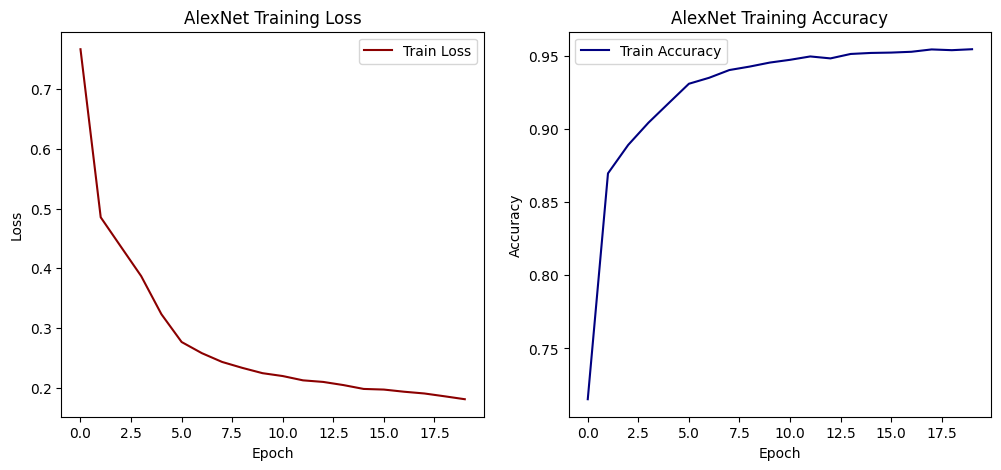

Final AlexNet Train Accuracy: 95.48%
AlexNet Test Accuracy: 62.28%
AlexNet Test F1-Score: 0.5102


In [ ]:
import matplotlib.pyplot as plt

num_epochs = 20
alex_train_losses = []
alex_train_accuracies = []

# --- TRAINING LOOP ---
for epoch in range(num_epochs):
    model_alexnet.train()
    epoch_loss = 0
    all_preds = []
    all_targets = []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Forward pass (Outputs logits)
        logits = model_alexnet(X_batch)
        
        # Compute BCE loss with logits
        loss = criterion(logits, y_batch)
        
        optimizer_alex.zero_grad()
        loss.backward()
        optimizer_alex.step()
        
        epoch_loss += loss.item()
        
        # Apply sigmoid just for the accuracy calculation
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.cpu().numpy())
        
    avg_loss = epoch_loss / len(train_loader)
    train_acc = accuracy_score(all_targets, all_preds)
    
    alex_train_losses.append(avg_loss)
    alex_train_accuracies.append(train_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {train_acc*100:.2f}%")

# --- PLOTTING ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(alex_train_losses, label='Train Loss', color='darkred')
plt.title('AlexNet Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(alex_train_accuracies, label='Train Accuracy', color='navy')
plt.title('AlexNet Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# --- EVALUATION ON TEST SET ---
model_alexnet.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model_alexnet(X_batch)
        
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(y_batch.cpu().numpy())

test_acc = accuracy_score(test_targets, test_preds)
test_f1 = f1_score(test_targets, test_preds)

print(f"Final AlexNet Train Accuracy: {alex_train_accuracies[-1]*100:.2f}%")
print(f"AlexNet Test Accuracy: {test_acc*100:.2f}%")
print(f"AlexNet Test F1-Score: {test_f1:.4f}")

### Task 7.3 (15 points): Early stopping

In Task 7.2 you trained AlexNet for a fixed number of epochs. In this task, you will implement **early stopping**.

1) Create a **validation set** by splitting the training set into **train/val** (suggested: 90% train, 10% val,  do this by spliting patient ID).  
2) Train for **50 epochs maximum**, but stop early if the **validation loss** has not improved for **patience = 5** consecutive epochs.  
3) Report the epoch where training stopped and the best validation loss achieved.
4) After training stops, restore the model weights from the best validation epoch (the saved best state) and evaluate the test set using that restored model. Report test Accuracy and F1 from the best state (not the final epoch).

**Output requirement:**
1) print one line per epoch in this format:

`Epoch [e/50], Train Loss: ..., Val Loss: ...`

2) At the end print:

`Early stopping at epoch E. Best epoch was B with Val Loss: ...`

3) Report test set accuracy and F1

In [ ]:
# Create a validation set by splitting the training set into train/val
# Your code here
# 1. Create a validation set by splitting patient IDs
split_idx = int(0.9 * len(pts_train))
pts_train_new = pts_train[:split_idx]
pts_val = pts_train[split_idx:]

# Run the task 2/3 processing on the new splits to avoid patient data leak
X_train_new, y_train_new = make_dataset(pts_train_new, num_sec, fs, abnormal)
X_val, y_val = make_dataset(pts_val, num_sec, fs, abnormal)

F_train_new = extract_features(X_train_new)
F_val = extract_features(X_val)

# Normalize using the NEW training data mean/std
mean_new = F_train_new.mean()
std_new = F_train_new.std()

F_train_norm_new = (F_train_new - mean_new) / std_new
F_val_norm = (F_val - mean_new) / std_new
# Make sure to normalize test data based on this new split too
F_test_norm_new = (F_test - mean_new) / std_new 

# Create the new DataLoaders
from torch.utils.data import TensorDataset, DataLoader

train_loader_new = DataLoader(TensorDataset(torch.from_numpy(F_train_norm_new).float(), 
                                            torch.from_numpy(y_train_new).float()), 
                              batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.from_numpy(F_val_norm).float(), 
                                      torch.from_numpy(y_val).float()), 
                        batch_size=256, shuffle=False)
# test_loader_new fix: We remove torch.from_numpy() because they are already tensors!
test_loader_new = DataLoader(TensorDataset(F_test_norm_new.float(), 
                                           y_test.float()), 
                             batch_size=256, shuffle=False)

Processing Patients: 100%|██████████| 4/4 [00:00<00:00,  8.56it/s]


In [ ]:
# Print the following. You should print patient IDs.
print("Train pts:", pts_train_new)
print("Val pts:", pts_val)

Train pts: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205']
Val pts: ['207', '208', '209', '210']


In [ ]:
# Extract features, rebuild TensorDatasets and Dataloaders with the train/val/test splits
# Your code here

In [ ]:
# Define loss function and optimizer
# Your code here

In [ ]:
# Train and test your model

Explain why early stopping can help in general. Did it help in your case?

Answer:

## Bonus Task (15 points)
---

Rebuild the training and test datasets using a new observation definition.

### Part A: Construct X and y
Each beat in MIT-BIH has an annotation (Normal or Abnormal). Define one observation as the ECG segment containing five consecutive beats:
- choose a center beat with a label
- include the two beats before and two beats after
- extract the signal from the sample index of the first beat to the fifth beat

Create:
- X = {x_i} for i=1..N, where each x_i is a 1D signal segment with length D_i (variable across samples)
- y is an N-by-1 label vector, where each region (heart beat) has its own label (0 = Normal, 1 = Abnormal)

Write a detailed explanation of how the five beats are selected (indexing logic, boundary cases) and how segment start/end are defined.


### Part B: Repeat Tasks
Repeat Task 3, Task 4, and Task 5, using the new dataset. In this case, the LSTM will have to provide a sequence as an output, labeling each heart beat, instead of a single pooled output.

### Required plots
Provide plots showing correctness: Plot at least 2 segments from the test set that include Normal and Abnormal heartbeats  with the five beat locations marked and the prediction of the LSTM for each of them. Compare them with the ground truth.


In [ ]:
import numpy as np
import scipy.signal
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import os

# --- PART A: CONSTRUCT X AND y ---
def make_bonus_dataset(pts, abnormal):
    X_list = []
    Y_list = []
    
    for pt in tqdm(pts, desc="Processing Bonus Patients"):
        path = os.path.join(path_dataset, str(pt))
        p_signal, symbol, index = load_ECG_file(path)
        
        # Filter valid beats
        valid_mask = np.isin(symbol, ['N'] + abnormal)
        valid_symbols = np.array(symbol)[valid_mask]
        valid_indices = np.array(index)[valid_mask]
        
        # Loop from the 3rd beat to the 3rd-to-last beat
        for i in range(2, len(valid_symbols) - 2):
            start_idx = valid_indices[i-2]
            end_idx = valid_indices[i+2]
            
            # Safety check to avoid out-of-bounds
            if start_idx >= 0 and end_idx < len(p_signal):
                segment = p_signal[start_idx : end_idx]
                X_list.append(segment)
                
                # Create a 5-label sequence
                window_syms = valid_symbols[i-2 : i+3]
                labels = [1 if sym in abnormal else 0 for sym in window_syms]
                Y_list.append(labels)
                
    return X_list, np.array(Y_list)

X_train_raw, y_train_b = make_bonus_dataset(pts_train, abnormal)
X_test_raw, y_test_b = make_bonus_dataset(pts_test, abnormal)

# Pad sequences to the maximum length
max_len = max(max(len(x) for x in X_train_raw), max(len(x) for x in X_test_raw))

def pad_sequences(sequences, max_len):
    padded = np.zeros((len(sequences), max_len))
    for i, seq in enumerate(sequences):
        padded[i, :len(seq)] = seq
    return padded

X_train_b_pad = pad_sequences(X_train_raw, max_len)
X_test_b_pad = pad_sequences(X_test_raw, max_len)

# --- PART B: REPEAT TASKS 3, 4, 5 ---

# Task 3: Feature Extraction
F_train_b = np.transpose(scipy.signal.spectrogram(X_train_b_pad, fs=360)[2], axes=(0, 2, 1))
F_test_b = np.transpose(scipy.signal.spectrogram(X_test_b_pad, fs=360)[2], axes=(0, 2, 1))

# Normalize
mean_b = F_train_b.mean()
std_b = F_train_b.std()
F_train_b_norm = (F_train_b - mean_b) / std_b
F_test_b_norm = (F_test_b - mean_b) / std_b

# Task 4: Dataloaders
train_loader_b = DataLoader(TensorDataset(torch.from_numpy(F_train_b_norm).float(), 
                                          torch.from_numpy(y_train_b).float()), 
                            batch_size=128, shuffle=True)
test_loader_b = DataLoader(TensorDataset(torch.from_numpy(F_test_b_norm).float(), 
                                         torch.from_numpy(y_test_b).float()), 
                           batch_size=128, shuffle=False)

# Task 5: Seq2Seq LSTM Model
class Seq2SeqLSTM(nn.Module):
    def __init__(self):
        super(Seq2SeqLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=129, hidden_size=64, num_layers=1, 
                            batch_first=True, bidirectional=True)
        # Magic Layer: Forces the Time dimension down to exactly 5 chunks!
        self.adaptive_pool = nn.AdaptiveAvgPool1d(5) 
        self.fc = nn.Linear(128, 1) # 128 because bidirectional (64*2)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm(x) # Shape: (Batch, Time, 128)
        
        # AdaptivePool expects (Batch, Channels, Length), so we transpose
        out = out.transpose(1, 2) # Shape: (Batch, 128, Time)
        out = self.adaptive_pool(out) # Shape: (Batch, 128, 5)
        out = out.transpose(1, 2) # Shape: (Batch, 5, 128)
        
        out = self.fc(out) # Shape: (Batch, 5, 1)
        return self.sigmoid(out).squeeze(-1) # Shape: (Batch, 5) 

# Training Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_bonus = Seq2SeqLSTM().to(device)
optimizer_b = torch.optim.Adam(model_bonus.parameters(), lr=0.001)

# Quick Training Loop
print("Training Bonus Seq2Seq Model...")
for epoch in range(15):
    model_bonus.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader_b:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        yhat = model_bonus(X_batch)
        # Standard PyTorch BCE is fine here since outputs are matched perfectly
        loss = nn.BCELoss()(yhat, y_batch) 
        optimizer_b.zero_grad()
        loss.backward()
        optimizer_b.step()
        epoch_loss += loss.item()
    print(f"Epoch [{epoch+1}/15], Loss: {epoch_loss/len(train_loader_b):.4f}")

Processing Bonus Patients: 100%|██████████| 16/16 [00:00<00:00, 22.50it/s]


: 

: 

: 

Your colab notebook link:



**You are ready to submit in Gradescope!**

Please suffix your colab file with _\<JHED ID\> (It's the part before the @ symbol in your email)

e.g. Lab3_ECG_LSTM_CNN_myjhedID

4 easy steps to submit your lab:

1.   Click on "Share" option on top right - Click on "copy link" option. Make sure your permission is set to "Anyone on the internet with this link can view". And paste it in the cell above.
2.   Go to "File" - "Download .ipynb" and "Download .py".
3.   Export the notebook to a PDF file with all the outputs.
3.   Upload the three files (.pdf, .ipynb, .py) to Gradescope.

That's it!